In [9]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


In [10]:
train_file_path = "/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv"
dataset_df = pd.read_csv(train_file_path)
print("Full train dataset shape is {}".format(dataset_df.shape))

Full train dataset shape is (1460, 81)


In [13]:
import tensorflow as tf
import tensorflow_decision_forests as tfdf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

tensorflow 머신러닝 프레임워크

tensorflow_decision_forests 랜덤 포레스트 등 트리 기반 모델

pandas 데이터 불러오기/가공

seaborn 데이터 시각화

matplotlib 그래프 출력

In [15]:
print("TensorFlow v" + tf.__version__)
print("TensorFlow Decision Forests v" + tfdf.__version__)

TensorFlow v2.19.0
TensorFlow Decision Forests v1.12.0


TensorFlow, TFDF 버전 확인

In [18]:
train_file_path = "/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv"
dataset_df = pd.read_csv(train_file_path)
print("Full train dataset shape is {}".format(dataset_df.shape))

Full train dataset shape is (1460, 81)


훈련 데이터 크기 출력

In [19]:
dataset_df.head(3)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


데이터 상위 3행 출력 head()만 입력시 기본값 5행 출력

In [21]:
dataset_df = dataset_df.drop('Id', axis=1)
dataset_df.head(3)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


Id 컬럼 삭제 (Id는 고유번호라 집 가격 예측에 도움x)

In [22]:
dataset_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

컬럼의 정보 출력(컬럼 이름, 데이터 타입(숫자/문자), 빈 값 확인)

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


/tmp/ipykernel_55/3430012634.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset_df['SalePrice'], color='g', bins=100, hist_kws={'alpha': 0.4});


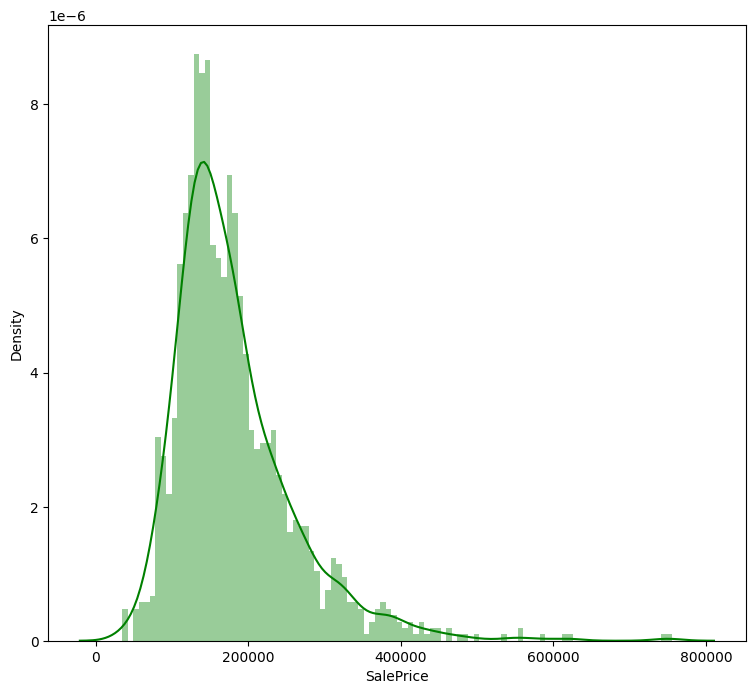

In [24]:
print(dataset_df['SalePrice'].describe())
plt.figure(figsize=(9, 8))
sns.distplot(dataset_df['SalePrice'], color='g', bins=100, hist_kws={'alpha': 0.4});

describe() : SalePrice 평균, 최솟값, 최댓값 등 기본 통계 수치 출력

sns.distplot() : SalePrice의 분포를 그래프로 시각화

In [25]:
list(set(dataset_df.dtypes.tolist()))

[dtype('float64'), dtype('O'), dtype('int64')]

dataset_df.dtypes : 각 컬럼의 데이터 타입 목록

set() : 중복 제거

list() : 결과를 리스트로 변환

<데이터 타입의 종류를 중복 없이 출력>

In [35]:
df_num = dataset_df.select_dtypes(include = ['float64', 'int64'])
df_num.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,0,61,0,0,0,0,0,2,2008,208500
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,298,0,0,0,0,0,0,5,2007,181500
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,0,42,0,0,0,0,0,9,2008,223500
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,0,35,272,0,0,0,0,2,2006,140000
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,192,84,0,0,0,0,0,12,2008,250000


숫자형 컬럼만 추출

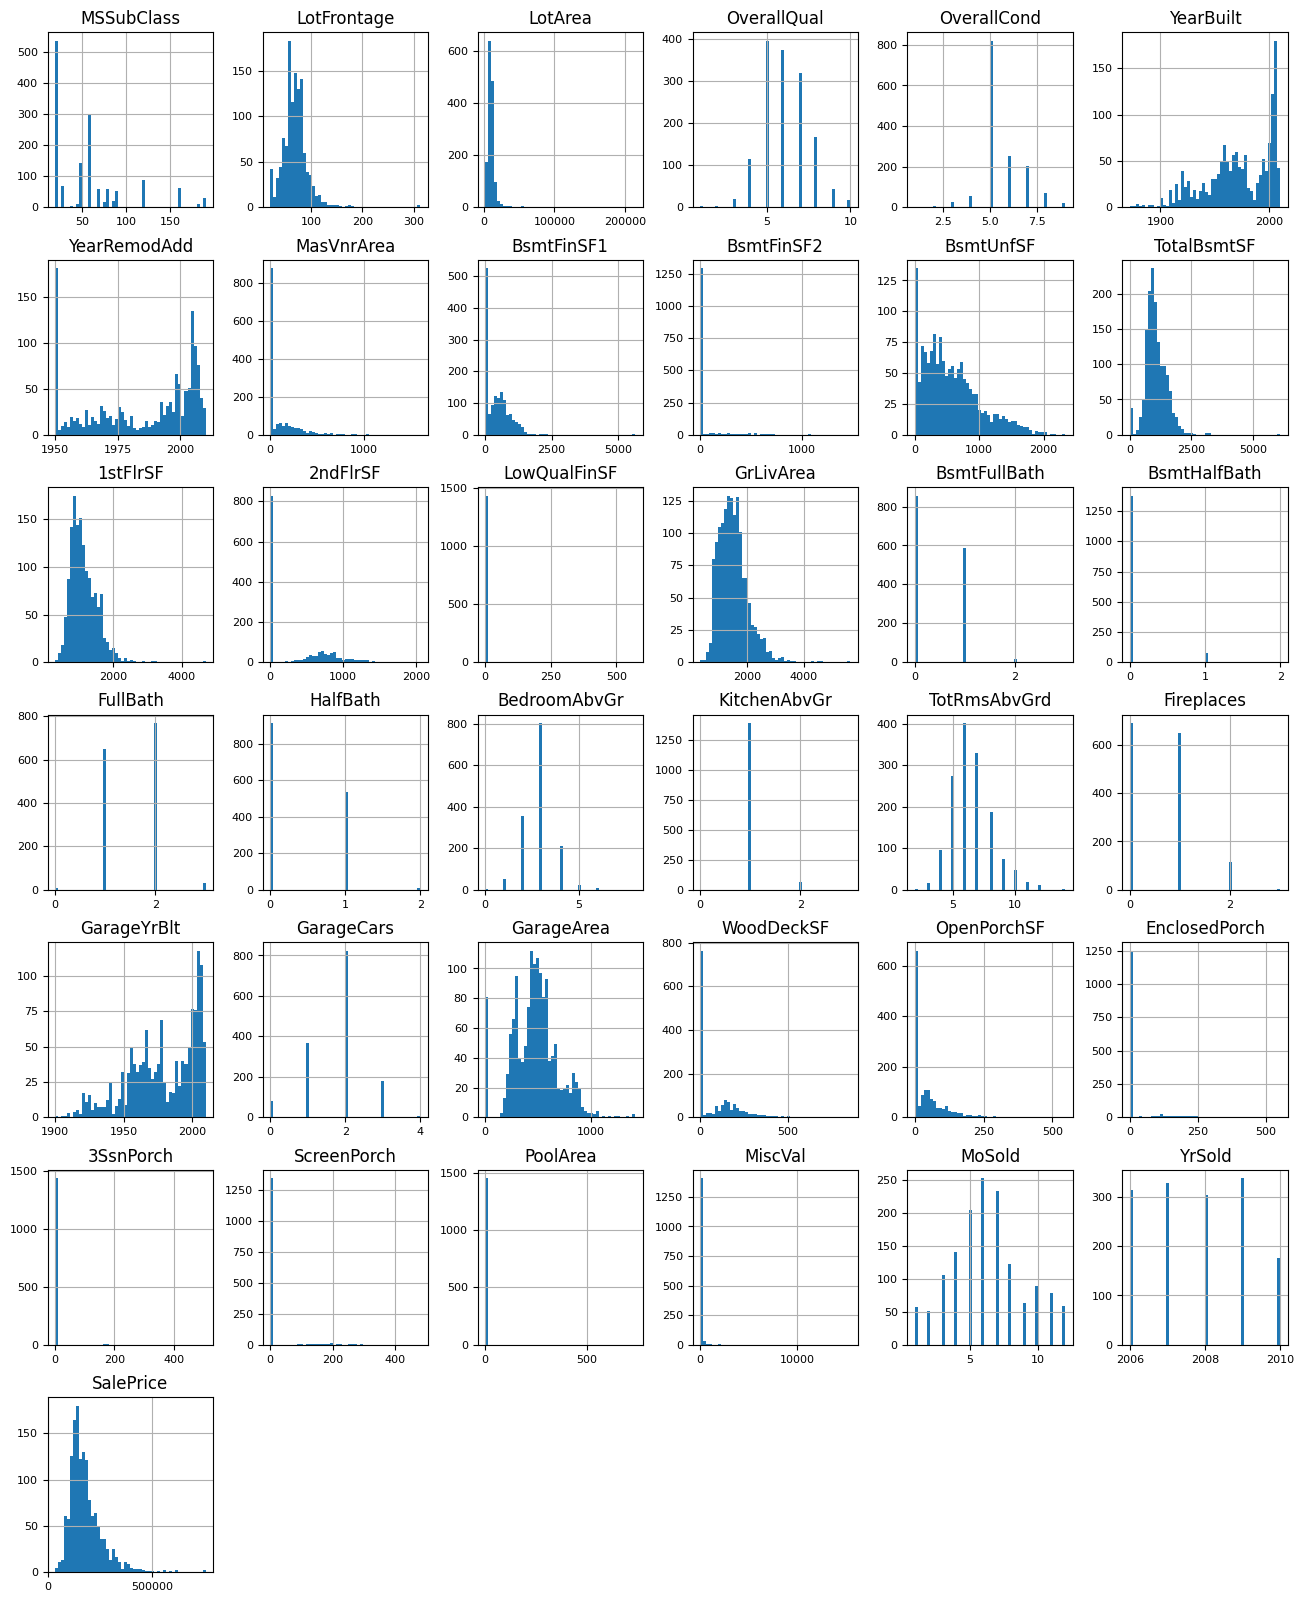

In [36]:
df_num.hist(figsize=(16, 20), bins=50, xlabelsize=8, ylabelsize=8);

숫자형 컬럼들의 분포를 한번에 히스토그램으로 시각화

figsize=(16, 20) : 전체 그래프 크기

bins=50 : 막대를 50개 구간으로 나눔

xlabelsize, ylabelsize : 축 글자 크기 조절


In [26]:
import numpy as np

def split_dataset(dataset, test_ratio=0.30):
  test_indices = np.random.rand(len(dataset)) < test_ratio
  return dataset[~test_indices], dataset[test_indices]

train_ds_pd, valid_ds_pd = split_dataset(dataset_df)
print("{} examples in training, {} examples in testing.".format(
    len(train_ds_pd), len(valid_ds_pd)))

982 examples in training, 478 examples in testing.


np.random.rand(len(dataset)) < test_ratio : 행마다 랜덤 숫자를 뽑아 30% 확률로 True/False 배열 생성

~test_indices : True/False 반전 (70% 학습용)

In [29]:
label = 'SalePrice'
train_ds = tfdf.keras.pd_dataframe_to_tf_dataset(train_ds_pd, label=label, task = tfdf.keras.Task.REGRESSION)
valid_ds = tfdf.keras.pd_dataframe_to_tf_dataset(valid_ds_pd, label=label, task = tfdf.keras.Task.REGRESSION)

REGRESSION : 집값, 온도처럼 숫자 예측

In [30]:
tfdf.keras.get_all_models()

[tensorflow_decision_forests.keras.RandomForestModel,
 tensorflow_decision_forests.keras.GradientBoostedTreesModel,
 tensorflow_decision_forests.keras.CartModel,
 tensorflow_decision_forests.keras.DistributedGradientBoostedTreesModel]

TFDF에서 사용 가능한 모델 목록을 출력

In [31]:
rf = tfdf.keras.RandomForestModel(task = tfdf.keras.Task.REGRESSION)
rf.compile(metrics=["mse"]) # Optional, you can use this to include a list of eval metrics

Use /tmp/tmp_x0ab5c_ as temporary training directory


랜덤 포레스트 모델을 생성하고 평가 기준을 설정

In [33]:
rf.fit(x=train_ds)

Reading training dataset...
Training dataset read in 0:00:00.066713. Found 982 examples.
Training model...


I0000 00:00:1776155620.612011      55 kernel.cc:782] Start Yggdrasil model training
I0000 00:00:1776155620.612064      55 kernel.cc:783] Collect training examples
I0000 00:00:1776155620.612084      55 kernel.cc:795] Dataspec guide:
column_guides {
  column_name_pattern: "^__LABEL$"
  type: NUMERICAL
}
default_column_guide {
  categorial {
    max_vocab_count: 2000
  }
  discretized_numerical {
    maximum_num_bins: 255
  }
}
ignore_columns_without_guides: false
detect_numerical_as_discretized_numerical: false

I0000 00:00:1776155620.612522      55 kernel.cc:401] Number of batches: 2
I0000 00:00:1776155620.612540      55 kernel.cc:402] Number of examples: 982
I0000 00:00:1776155620.614592      55 data_spec_inference.cc:354] 1 item(s) have been pruned (i.e. they are considered out of dictionary) for the column BsmtCond (3 item(s) left) because min_value_count=5 and max_number_of_unique_values=2000
I0000 00:00:1776155620.614658      55 data_spec_inference.cc:354] 2 item(s) have been prune

Model trained in 0:00:01.890039
Compiling model...


I0000 00:00:1776155622.473669      55 decision_forest.cc:808] Model loaded with 300 root(s), 93214 node(s), and 73 input feature(s).


Model compiled.


모델을 학습시키는 코드

랜덤 포레스트는 딥러닝과 달리 epoch(반복 학습) 없이 데이터를 한 번만 읽고 학습.

In [34]:
tfdf.model_plotter.plot_model_in_colab(rf, tree_idx=0, max_depth=3)

학습된 랜덤 포레스트의 트리를 시각화

tree_idx=0 : 랜덤 포레스트 안에 있는 첫 번째 트리를 선택

max_depth=3 : 트리를 3단계 깊이까지만 표시 

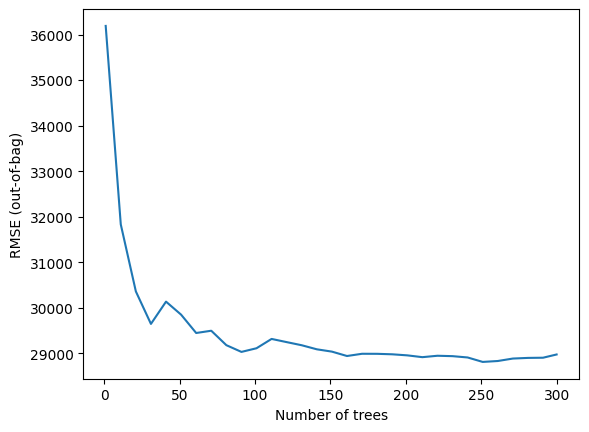

In [37]:
import matplotlib.pyplot as plt
logs = rf.make_inspector().training_logs()
plt.plot([log.num_trees for log in logs], [log.evaluation.rmse for log in logs])
plt.xlabel("Number of trees")
plt.ylabel("RMSE (out-of-bag)")
plt.show()

트리 개수에 따른 모델 성능 변화를 그래프로 시각화

In [38]:
inspector = rf.make_inspector()
inspector.evaluation()

Evaluation(num_examples=982, accuracy=None, loss=None, rmse=28975.0236744669, ndcg=None, aucs=None, auuc=None, qini=None)

학습된 모델의 최종 성능 지표를 출력

In [39]:
evaluation = rf.evaluate(x=valid_ds,return_dict=True)

for name, value in evaluation.items():
  print(f"{name}: {value:.4f}")

1/1 [==============================] - 1s 669ms/step - loss: 0.0000e+00 - mse: 939718336.0000
loss: 0.0000
mse: 939718336.0000


검증 데이터로 모델 성능을 최종 확인

In [40]:
print(f"Available variable importances:")
for importance in inspector.variable_importances().keys():
  print("\t", importance)

Available variable importances:
	 INV_MEAN_MIN_DEPTH
	 NUM_AS_ROOT
	 SUM_SCORE
	 NUM_NODES


사용 가능한 변수 중요도 종류를 출력

variable_importances() : 각 컬럼이 예측에 얼마나 영향을 미쳤는지 측정한 지표들

.keys() : 그 지표들의 이름 목록만 출력

In [ ]:
inspector.variable_importances()["NUM_AS_ROOT"]

NUM_AS_ROOT 변수 중요도를 출력

NUM_AS_ROOT : 각 트리의 맨 첫 번째 루트에 몇 번 사용됐는지 횟수를 집계

(루트에 자주 등장할수록 예측에 가장 핵심적인 컬럼이어서)

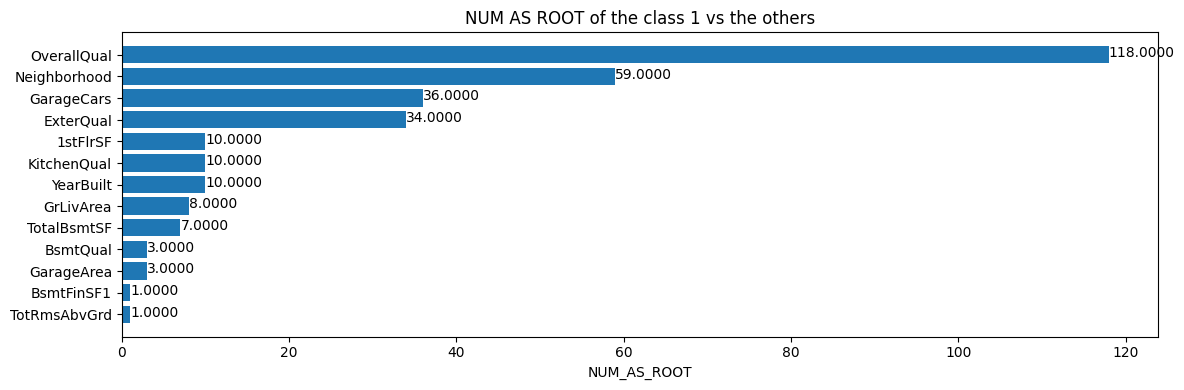

In [41]:
plt.figure(figsize=(12, 4))

variable_importance_metric = "NUM_AS_ROOT"
variable_importances = inspector.variable_importances()[variable_importance_metric]

feature_names = [vi[0].name for vi in variable_importances]
feature_importances = [vi[1] for vi in variable_importances]
feature_ranks = range(len(feature_names))

bar = plt.barh(feature_ranks, feature_importances, label=[str(x) for x in feature_ranks])
plt.yticks(feature_ranks, feature_names)
plt.gca().invert_yaxis()

for importance, patch in zip(feature_importances, bar.patches):
  plt.text(patch.get_x() + patch.get_width(), patch.get_y(), f"{importance:.4f}", va="top")

plt.xlabel(variable_importance_metric)
plt.title("NUM AS ROOT of the class 1 vs the others")
plt.tight_layout()
plt.show()

<변수의 중요도를 가로 막대 그래프로 시각화>

feature_names : 컬럼 이름 추출

feature_importances : 중요도 수치 추출

plt.barh() : 가로 막대 그래프 생성

invert_yaxis() : 중요도 높은 순으로 위에서 아래로 정렬

plt.text() : 각 막대 끝에 수치를 표시

In [55]:
test_file_path = "/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv"
test_data = pd.read_csv(test_file_path)
ids = test_data.pop('Id')

test_ds = tfdf.keras.pd_dataframe_to_tf_dataset(
    test_data,
    task = tfdf.keras.Task.REGRESSION)

preds = rf.predict(test_ds)
output = pd.DataFrame({'Id' : ids, 'SalePrice': preds.squeeze()})

output.head()

2/2 [==============================] - 1s 22ms/step


,Id,SalePrice
0,1461,128019.507812
1,1462,155093.296875
2,1463,178291.937500
3,1464,184549.046875
4,1465,201588.750000


<test 데이터로 집값을 예측>

test_data.pop('Id') : Id 컬럼을 따로 저장하면서 삭제 (예측엔 불필요, 제출시 필요)

rf.predict(test_ds) : 학습된 모델로 집값 예측

preds.squeeze() : 예측 결과 배열을 1차원으로 변환

pd.DataFrame({'Id': ids, 'SalePrice': preds}) : 제출 형식에 맞게 Id + 예측값으로 조합

In [56]:
sample_submission_df = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv')
sample_submission_df['SalePrice'] = rf.predict(test_ds)
sample_submission_df.to_csv('/kaggle/working/submission.csv', index=False)
sample_submission_df.head()

2/2 [==============================] - 0s 22ms/step


,Id,SalePrice
0,1461,128019.507812
1,1462,155093.296875
2,1463,178291.937500
3,1464,184549.046875
4,1465,201588.750000
